# 10 · Inferencia final y geografía de la brecha — Bogotá 2023

**Especificación principal predefinida:** referencia poblacional completa, destinos
`core_50`, FPT condicionado a iniciar fuera del conjunto objetivo y contracción
$\tau=20$.

Este notebook aumenta el bootstrap Poisson por hogar de 50 a **500 réplicas**, estima
intervalos percentiles y simultáneos para empleo, educación y salud, y localiza por UTAM
las contribuciones a la brecha mujer–hombre.

Para cada origen $i$, con distribuciones residenciales condicionadas
$\mu_i^{(w)},\mu_i^{(m)}$ y FPT $h_i^{(w)},h_i^{(m)}$, la descomposición simétrica es

$$
R_i=(\mu_i^{(w)}-\mu_i^{(m)})\frac{h_i^{(w)}+h_i^{(m)}}{2},\qquad
K_i=(h_i^{(w)}-h_i^{(m)})\frac{\mu_i^{(w)}+\mu_i^{(m)}}{2}.
$$

Entonces $\sum_i(R_i+K_i)$ reproduce exactamente la brecha total. Los mapas son una
atribución descriptiva, no una identificación causal de efectos territoriales.


In [29]:
%pip -q install pandas pyarrow numpy scipy matplotlib seaborn geopandas


In [30]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import hashlib
import json
import os
import re
import shutil
import unicodedata
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate11"
OUT = ROOT / "outputs/bogota_em2023/gate11"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (RAW, INTERIM, OUT):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_URL = (
    "https://observatorio.movilidadbogota.gov.co/sites/default/files/"
    "2025-09/05_Base%20datos%20procesada%20EODH.zip"
)
ZONING_URL = (
    "https://observatorio.movilidadbogota.gov.co/sites/default/files/"
    "2025-09/03_Zonificacion%20EODH%20%281%29.zip"
)
PURPOSES = ("employment", "education", "health")
TARGET_DEFINITION = "core_50"
TARGET_DEFINITIONS = ("core_50", "extended_80")
CONDITIONING = "outside_target"
PRIMARY_TAU = 20.0
BOOTSTRAP_REPLICATES = 500
RANDOM_SEED = 202311

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

gate4_dir = Path(os.environ.get("GATE4_DIR_OVERRIDE", DRIVE_BASE / "results/gate4"))
gate6_dir = Path(os.environ.get("GATE6_DIR_OVERRIDE", DRIVE_BASE / "results/gate6"))
gate9_dir = Path(os.environ.get("GATE9_DIR_OVERRIDE", DRIVE_BASE / "results/gate9"))
gate10_dir = Path(os.environ.get("GATE10_DIR_OVERRIDE", DRIVE_BASE / "results/gate10"))
EDGE_PATH = gate4_dir / "transition_edges_utam.parquet"
TARGET_PATH = gate6_dir / "purpose_target_sets.csv"
GATE9_POINT_PATH = gate9_dir / "residence_kernel_decomposition.csv"
GATE9_SEX_PATH = gate9_dir / "female_male_decomposition.csv"
GATE10_PATH = gate10_dir / "gate_10.json"

required_paths = (
    EDGE_PATH, TARGET_PATH, GATE9_POINT_PATH, GATE9_SEX_PATH, GATE10_PATH,
)
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Faltan insumos validados: " + ", ".join(missing))

gate10 = json.loads(GATE10_PATH.read_text(encoding="utf-8"))
gate10_status = gate10.get("gate", gate10)
if not bool(gate10_status.get("gate_10_passed", False)):
    raise RuntimeError("La Compuerta 10 no fue aprobada.")

print("Especificación: full_population / core_50 / outside_target / tau=20")
print("Réplicas bootstrap:", BOOTSTRAP_REPLICATES)
print("Salida:", OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Especificación: full_population / core_50 / outside_target / tau=20
Réplicas bootstrap: 500
Salida: /content/colombia-stochastic-access/outputs/bogota_em2023/gate11


## 1. Recuperación de microdatos y zonificación

Se reutilizan los dos ZIP oficiales almacenados en Drive. Si la zonificación no está en
caché, el notebook solicitará una única carga manual adicional.


In [31]:
def sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)


def upload_archive(destination):
    from google.colab import files
    print("Descargue el ZIP oficial si no lo conserva:")
    print(SOURCE_URL)
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Suba exactamente un archivo ZIP.")
    name, content = next(iter(uploaded.items()))
    temporary = destination.with_suffix(".zip.upload")
    temporary.write_bytes(content)
    del content
    if not valid_zip(temporary):
        temporary.unlink(missing_ok=True)
        raise ValueError(f"{name} no es un ZIP válido.")
    temporary.replace(destination)
    return "manual_upload"


archive = RAW / "processed_edoh.zip"
drive_archive = DRIVE_BASE / "processed_edoh.zip"
if valid_zip(archive):
    retrieval_method = "runtime_cache"
elif valid_zip(drive_archive):
    shutil.copy2(drive_archive, archive)
    retrieval_method = "google_drive_cache"
else:
    retrieval_method = upload_archive(archive)
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    shutil.copy2(archive, drive_archive)


def safe_extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    queue = [(Path(zip_path), destination)]
    visited = set()
    while queue:
        current, target = queue.pop(0)
        signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited:
            continue
        visited.add(signature)
        root = target.resolve()
        with zipfile.ZipFile(current) as zipped:
            for member in zipped.infolist():
                resolved = (target / member.filename).resolve()
                if root != resolved and root not in resolved.parents:
                    raise ValueError(f"Ruta insegura en ZIP: {member.filename}")
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            nested_signature = (str(nested.resolve()), str(nested_target.resolve()))
            if nested_signature not in visited:
                queue.append((nested, nested_target))


safe_extract_recursive(archive, INTERIM / "processed_edoh")
source_manifest = pd.DataFrame([{
    "source_id": "processed_edoh", "url": SOURCE_URL, "path": str(archive),
    "bytes": int(archive.stat().st_size), "sha256": sha256(archive),
    "retrieval_method": retrieval_method,
    "generated_utc": datetime.now(timezone.utc).isoformat(),
}])
source_manifest.to_csv(OUT / "source_manifest.csv", index=False)
display(source_manifest)


,source_id,url,path,bytes,sha256,retrieval_method,generated_utc
0,processed_edoh,https://observatorio.movilidadbogota.gov.co/si...,/content/colombia-stochastic-access/data/raw/b...,88826883,2509410f39713de4768872952e75e95809a99d7edf5b65...,runtime_cache,2026-09-11T20:47:23.372715+00:00


In [32]:
def ensure_zoning_archive():
    runtime = RAW / "zoning_edoh.zip"
    cached = DRIVE_BASE / "zoning_edoh.zip"
    if valid_zip(runtime):
        method = "runtime_cache"
    elif valid_zip(cached):
        shutil.copy2(cached, runtime)
        method = "google_drive_cache"
    else:
        from google.colab import files
        print("Descargue y seleccione el ZIP de zonificación:")
        print(ZONING_URL)
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Suba exactamente un archivo ZIP de zonificación.")
        name, content = next(iter(uploaded.items()))
        temporary = runtime.with_suffix(".zip.upload")
        temporary.write_bytes(content)
        del content
        if not valid_zip(temporary):
            temporary.unlink(missing_ok=True)
            raise ValueError(f"{name} no es un ZIP válido.")
        temporary.replace(runtime)
        DRIVE_BASE.mkdir(parents=True, exist_ok=True)
        shutil.copy2(runtime, cached)
        method = "manual_upload"
    return runtime, method


zoning_archive, zoning_retrieval_method = ensure_zoning_archive()
safe_extract_recursive(zoning_archive, INTERIM / "zoning_edoh")
print("Zonificación:", zoning_retrieval_method, zoning_archive)


Zonificación: runtime_cache /content/colombia-stochastic-access/data/raw/bogota_em2023/zoning_edoh.zip


In [33]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(char for char in value if not unicodedata.combining(char))
    return re.sub(r"[^a-z0-9]+", "_", value.lower().strip()).strip("_")


def clean_key(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    invalid = cleaned.map(normalize).isin(
        ["", "nan", "none", "na", "no_aplica", "sin_informacion"]
    )
    return cleaned.mask(invalid)


def canonical_utam(series):
    cleaned = clean_key(series)
    def canonical(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        upr = re.fullmatch(r"UPR0*(\d+)", text)
        if upr:
            return f"UPR{int(upr.group(1)):04d}"
        utam = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        if utam:
            return f"UTAM{int(utam.group(1)):03d}"
        return text
    return cleaned.map(canonical).astype("string")


def parse_number(series):
    raw = series.astype("string").str.strip()
    if float(raw.str.contains(",", regex=False, na=False).mean()) > 0.05:
        raw = raw.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")


def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle:
                sample = handle.read(32768)
            return encoding, csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except (UnicodeDecodeError, csv.Error):
            continue
    raise ValueError(f"No fue posible detectar el formato: {path}")


def find_module(token, excluded=()):
    paths = list((INTERIM / "processed_edoh").rglob("*.csv"))
    candidates = [
        path for path in paths
        if token in normalize(path.stem)
        and not any(item in normalize(path.stem) for item in excluded)
    ]
    if not candidates:
        raise FileNotFoundError(f"No se encontró el módulo CSV: {token}")
    return sorted(candidates, key=lambda path: (len(path.parts), len(path.name)))[0]


def read_selected(path, required):
    encoding, delimiter = csv_format(path)
    header = pd.read_csv(path, sep=delimiter, encoding=encoding, nrows=0)
    mapping = {normalize(column): column for column in header.columns}
    absent = sorted(set(required) - set(mapping))
    if absent:
        raise KeyError(f"Faltan columnas en {path.name}: {absent}")
    frame = pd.read_csv(
        path, sep=delimiter, encoding=encoding,
        usecols=[mapping[column] for column in required], dtype="string", low_memory=False,
    )
    frame.columns = [normalize(column) for column in frame.columns]
    return frame


trips = read_selected(
    find_module("viaje", excluded=("etapa",)),
    ["key_hg", "utam_ori", "utam_des", "fexp_vj", "sexo", "estra_hg"],
)
persons = read_selected(
    find_module("persona"),
    ["key_hg", "cod_utam_hg", "fexp_per_5anos", "sexo", "estra_hg"],
)

trips["household"] = clean_key(trips["key_hg"])
trips["utam_ori"] = canonical_utam(trips["utam_ori"])
trips["utam_des"] = canonical_utam(trips["utam_des"])
trips["weight"] = parse_number(trips["fexp_vj"])
trips["sex_group"] = trips["sexo"].map(normalize)
trips["stratum_group"] = clean_key(trips["estra_hg"])
trips = trips[
    trips[["household", "utam_ori", "utam_des"]].notna().all(axis=1)
    & trips["weight"].gt(0)
].reset_index(drop=True)

persons["household"] = clean_key(persons["key_hg"])
persons["residence_utam"] = canonical_utam(persons["cod_utam_hg"])
persons["weight"] = parse_number(persons["fexp_per_5anos"])
persons["sex_group"] = persons["sexo"].map(normalize)
persons["stratum_group"] = clean_key(persons["estra_hg"])
persons = persons[
    persons[["household", "residence_utam"]].notna().all(axis=1)
    & persons["weight"].gt(0)
].reset_index(drop=True)

print("Viajes válidos:", f"{len(trips):,}")
print("Personas válidas:", f"{len(persons):,}")


Viajes válidos: 97,796
Personas válidas: 64,989


## 2. Soporte analítico y funciones

Se reconstruye exactamente el soporte de Gate 9. Las categorías faltantes se mantienen
fuera de los grupos, pero la referencia principal continúa siendo toda la población.


In [34]:
VALID_LEVELS = {
    "sex": ("mujer", "hombre"),
    "stratum": tuple(map(str, range(1, 7))),
}


def validity_mask(frame, dimension):
    column = "sex_group" if dimension == "sex" else "stratum_group"
    return frame[column].isin(VALID_LEVELS[dimension]).fillna(False).to_numpy(dtype=bool)


audit_rows = []
for module, frame in (("persons", persons), ("trips", trips)):
    for dimension in VALID_LEVELS:
        mask = validity_mask(frame, dimension)
        audit_rows.append({
            "module": module, "dimension": dimension,
            "rows": int(len(frame)), "valid_rows": int(mask.sum()),
            "row_valid_share": float(mask.mean()),
            "total_weight": float(frame["weight"].sum()),
            "valid_weight": float(frame.loc[mask, "weight"].sum()),
            "weighted_valid_share": float(frame.loc[mask, "weight"].sum() / frame["weight"].sum()),
        })
category_coverage = pd.DataFrame(audit_rows)
category_coverage.to_csv(OUT / "category_coverage_audit.csv", index=False)

excluded_rows = []
for module, frame in (("persons", persons), ("trips", trips)):
    for dimension in VALID_LEVELS:
        column = "sex_group" if dimension == "sex" else "stratum_group"
        valid = validity_mask(frame, dimension)
        excluded = frame.loc[~valid].copy()
        labels = excluded[column].fillna("<missing>")
        summary = excluded.assign(label=labels).groupby("label", dropna=False).agg(
            rows=("weight", "size"), weighted_count=("weight", "sum")
        ).reset_index()
        for row in summary.itertuples(index=False):
            excluded_rows.append({
                "module": module, "dimension": dimension, "label": str(row.label),
                "rows": int(row.rows), "weighted_count": float(row.weighted_count),
            })
excluded_categories = pd.DataFrame(excluded_rows)
excluded_categories.to_csv(OUT / "excluded_category_audit.csv", index=False)
display(category_coverage)
display(excluded_categories)


,module,dimension,rows,valid_rows,row_valid_share,total_weight,valid_weight,weighted_valid_share
0,persons,sex,64989,64975,0.999785,9273186.5,9270389.5,0.999698
1,persons,stratum,64989,48989,0.753804,9273186.5,7451684.8,0.803573
2,trips,sex,97796,97779,0.999826,16440081.3,16435537.0,0.999724
3,trips,stratum,97796,77300,0.790421,16440081.3,13816305.2,0.840404


,module,dimension,label,rows,weighted_count
0,persons,sex,intersexual,14,2797.0
1,persons,stratum,<missing>,16000,1821501.7
2,trips,sex,intersexual,17,4544.3
3,trips,stratum,<missing>,20496,2623776.1


In [35]:
edges = pd.read_parquet(EDGE_PATH).copy()
for column in ("utam_ori", "utam_des"):
    edges[column] = canonical_utam(edges[column])
edges = edges.dropna(subset=["utam_ori", "utam_des"])
nodes = sorted(set(edges["utam_ori"]) | set(edges["utam_des"]))
node_to_index = {node: index for index, node in enumerate(nodes)}
n_nodes = len(nodes)

P0 = np.zeros((n_nodes, n_nodes), dtype=float)
for row in edges.itertuples(index=False):
    P0[node_to_index[row.utam_ori], node_to_index[row.utam_des]] = float(
        row.transition_probability
    )
if not np.allclose(P0.sum(axis=1), 1.0, atol=1e-10):
    raise RuntimeError("El kernel poblacional no es estocástico.")

trip_support = trips["utam_ori"].isin(node_to_index) & trips["utam_des"].isin(node_to_index)
person_support = persons["residence_utam"].isin(node_to_index)
support_audit = pd.DataFrame([{
    "trip_weight_support_share": float(
        trips.loc[trip_support, "weight"].sum() / trips["weight"].sum()
    ),
    "person_weight_residential_support_share": float(
        persons.loc[person_support, "weight"].sum() / persons["weight"].sum()
    ),
}])
support_audit.to_csv(OUT / "robustness_support_audit.csv", index=False)
trips = trips.loc[trip_support].reset_index(drop=True)
persons = persons.loc[person_support].reset_index(drop=True)

origin_index = trips["utam_ori"].map(node_to_index).to_numpy(dtype=int)
destination_index = trips["utam_des"].map(node_to_index).to_numpy(dtype=int)
base_trip_weight = trips["weight"].to_numpy(dtype=float)
residence_index = persons["residence_utam"].map(node_to_index).to_numpy(dtype=int)
base_person_weight = persons["weight"].to_numpy(dtype=float)

target_table = pd.read_csv(TARGET_PATH, dtype={"utam": "string"})
target_table["utam"] = target_table["utam"].astype("string").str.strip().str.upper()
target_sets = {}
for purpose in PURPOSES:
    for definition in TARGET_DEFINITIONS:
        codes = set(target_table.loc[
            target_table["purpose_group"].eq(purpose)
            & target_table["target_definition"].eq(definition), "utam"
        ])
        missing_codes = sorted(codes - set(nodes))
        if not codes or missing_codes:
            raise RuntimeError(
                f"Objetivo inválido {purpose}/{definition}; fuera del kernel: {missing_codes}"
            )
        target_sets[(purpose, definition)] = np.array(
            sorted(node_to_index[code] for code in codes), dtype=int
        )

expected_groups = {
    "sex:mujer": ("sex", "mujer"),
    "sex:hombre": ("sex", "hombre"),
}
for level in map(str, range(1, 7)):
    expected_groups[f"stratum:{level}"] = ("stratum", level)


def group_mask(frame, dimension, level):
    column = "sex_group" if dimension == "sex" else "stratum_group"
    return frame[column].eq(level).fillna(False).to_numpy(dtype=bool)


trip_masks = {gid: group_mask(trips, dim, level) for gid, (dim, level) in expected_groups.items()}
person_masks = {gid: group_mask(persons, dim, level) for gid, (dim, level) in expected_groups.items()}
reference_trip_masks = {dim: validity_mask(trips, dim) for dim in VALID_LEVELS}
reference_person_masks = {dim: validity_mask(persons, dim) for dim in VALID_LEVELS}

print("Nodos:", n_nodes)
print("Objetivos:", {f"{p}/{d}": len(t) for (p, d), t in target_sets.items()})
display(support_audit)


Nodos: 141
Objetivos: {'employment/core_50': 30, 'employment/extended_80': 69, 'education/core_50': 29, 'education/extended_80': 66, 'health/core_50': 19, 'health/extended_80': 50}


,trip_weight_support_share,person_weight_residential_support_share
0,1.0,0.998209


In [36]:
def regularized_kernel(mask, tau, pool, row_multiplier=None):
    selected = np.flatnonzero(mask)
    original = base_trip_weight[selected]
    multiplicity = (
        np.ones(len(selected), dtype=float)
        if row_multiplier is None else row_multiplier[selected].astype(float)
    )
    weights = original * multiplicity
    squared = original**2 * multiplicity
    origins = origin_index[selected]
    destinations = destination_index[selected]
    positive = weights > 0
    weights, squared = weights[positive], squared[positive]
    origins, destinations = origins[positive], destinations[positive]
    W = np.zeros((n_nodes, n_nodes), dtype=float)
    np.add.at(W, (origins, destinations), weights)
    out = W.sum(axis=1)
    sum_sq = np.bincount(origins, weights=squared, minlength=n_nodes)
    ess = np.divide(out**2, sum_sq, out=np.zeros(n_nodes), where=sum_sq > 0)
    empirical = np.zeros_like(W)
    observed = out > 0
    empirical[observed] = W[observed] / out[observed, None]
    omega = ess / (ess + float(tau))
    return omega[:, None] * empirical + (1.0 - omega[:, None]) * pool


def residential_distribution(mask=None, row_multiplier=None):
    if mask is None:
        mask = np.ones(len(persons), dtype=bool)
    selected = np.flatnonzero(mask)
    multiplicity = (
        np.ones(len(selected), dtype=float)
        if row_multiplier is None else row_multiplier[selected].astype(float)
    )
    weights = base_person_weight[selected] * multiplicity
    mu = np.bincount(residence_index[selected], weights=weights, minlength=n_nodes).astype(float)
    if not np.isfinite(mu).all() or mu.sum() <= 0:
        raise RuntimeError("Distribución residencial vacía o no finita.")
    return mu / mu.sum()


def first_passage_by_origin(P, targets):
    target_mask = np.zeros(n_nodes, dtype=bool)
    target_mask[targets] = True
    transient = np.flatnonzero(~target_mask)
    Q = P[np.ix_(transient, transient)]
    mean = np.linalg.solve(np.eye(len(transient)) - Q, np.ones(len(transient)))
    full = np.zeros(n_nodes, dtype=float)
    full[transient] = mean
    return full


def mean_fpt(h, mu, targets, conditioning):
    if conditioning == "all_residences":
        return float(mu @ h)
    eligible = np.ones(n_nodes, dtype=bool)
    eligible[targets] = False
    mass = float(mu[eligible].sum())
    if mass <= 0:
        raise RuntimeError("No hay masa residencial fuera del objetivo.")
    return float((mu[eligible] / mass) @ h[eligible])


def factorial_values(href, hg, muref, mug, targets, conditioning):
    B = mean_fpt(href, muref, targets, conditioning)
    C = mean_fpt(href, mug, targets, conditioning)
    K = mean_fpt(hg, muref, targets, conditioning)
    G = mean_fpt(hg, mug, targets, conditioning)
    residential = C - B
    kernel = K - B
    interaction = G - C - K + B
    total = G - B
    return {
        "reference_baseline": B, "residence_only": C,
        "kernel_only": K, "group_observed": G,
        "residential_main": residential, "kernel_main": kernel,
        "interaction": interaction,
        "shapley_residential": residential + 0.5 * interaction,
        "shapley_kernel": kernel + 0.5 * interaction,
        "total_gap": total,
        "closure_error": total - residential - kernel - interaction,
    }


def sex_gap_values(h_w, h_m, mu_w, mu_m, targets, conditioning):
    mm = mean_fpt(h_m, mu_m, targets, conditioning)
    mw = mean_fpt(h_m, mu_w, targets, conditioning)
    wm = mean_fpt(h_w, mu_m, targets, conditioning)
    ww = mean_fpt(h_w, mu_w, targets, conditioning)
    residential = 0.5 * ((mw - mm) + (ww - wm))
    kernel = 0.5 * ((wm - mm) + (ww - mw))
    total = ww - mm
    return {
        "male_total_fpt": mm, "female_total_fpt": ww,
        "female_minus_male_total": total,
        "residential_contribution": residential,
        "kernel_contribution": kernel,
        "closure_error": total - residential - kernel,
    }


## 3. Estimaciones puntuales y contribuciones por origen

Las contribuciones residenciales y del kernel se calculan en el mismo soporte condicionado
y su suma se verifica contra la brecha agregada para cada propósito.


In [37]:
mu0 = residential_distribution()
group_mu = {gid: residential_distribution(person_masks[gid]) for gid in expected_groups}
group_kernels = {
    gid: regularized_kernel(trip_masks[gid], PRIMARY_TAU, P0)
    for gid in expected_groups
}


def conditioned_mu(mu, targets):
    result = mu.copy()
    result[targets] = 0.0
    if result.sum() <= 0:
        raise RuntimeError("Distribución condicionada vacía.")
    return result / result.sum()


point_rows = []
sex_rows = []
origin_rows = []
h0_by_purpose = {}
h_group = {}
for purpose in PURPOSES:
    targets = target_sets[(purpose, TARGET_DEFINITION)]
    h0 = first_passage_by_origin(P0, targets)
    h0_by_purpose[purpose] = h0
    for gid, (dimension, level) in expected_groups.items():
        hg = first_passage_by_origin(group_kernels[gid], targets)
        h_group[(gid, purpose)] = hg
        values = factorial_values(h0, hg, mu0, group_mu[gid], targets, CONDITIONING)
        point_rows.append({
            "group_id": gid, "dimension": dimension, "level": level,
            "purpose_group": purpose, **values,
        })

    h_w = h_group[("sex:mujer", purpose)]
    h_m = h_group[("sex:hombre", purpose)]
    mu_w = conditioned_mu(group_mu["sex:mujer"], targets)
    mu_m = conditioned_mu(group_mu["sex:hombre"], targets)
    sex_values = sex_gap_values(h_w, h_m, group_mu["sex:mujer"],
                                group_mu["sex:hombre"], targets, CONDITIONING)
    sex_rows.append({"purpose_group": purpose, **sex_values})

    residential_i = (mu_w - mu_m) * (h_w + h_m) / 2.0
    kernel_i = (h_w - h_m) * (mu_w + mu_m) / 2.0
    for index, node in enumerate(nodes):
        origin_rows.append({
            "purpose_group": purpose, "utam": node,
            "female_residential_probability": float(mu_w[index]),
            "male_residential_probability": float(mu_m[index]),
            "female_fpt_steps": float(h_w[index]),
            "male_fpt_steps": float(h_m[index]),
            "residential_contribution": float(residential_i[index]),
            "kernel_contribution": float(kernel_i[index]),
            "total_contribution": float(residential_i[index] + kernel_i[index]),
        })

point = pd.DataFrame(point_rows)
sex_point = pd.DataFrame(sex_rows)
origin_contributions = pd.DataFrame(origin_rows)
point.to_csv(OUT / "final_group_decomposition_point_estimates.csv", index=False)
sex_point.to_csv(OUT / "final_female_male_point_estimates.csv", index=False)
origin_contributions.to_csv(OUT / "female_male_origin_contributions.csv", index=False)

origin_closure = origin_contributions.groupby("purpose_group", observed=True).agg(
    residential_sum=("residential_contribution", "sum"),
    kernel_sum=("kernel_contribution", "sum"),
    total_sum=("total_contribution", "sum"),
).reset_index().merge(sex_point, on="purpose_group")
origin_closure["closure_error"] = (
    origin_closure["total_sum"] - origin_closure["female_minus_male_total"]
)
origin_closure.to_csv(OUT / "origin_contribution_closure.csv", index=False)
display(sex_point)
display(origin_closure)


,purpose_group,male_total_fpt,female_total_fpt,female_minus_male_total,residential_contribution,kernel_contribution,closure_error
0,employment,4.111272,5.110021,0.998749,-0.032536,1.031285,0.0
1,education,4.305536,5.132898,0.827362,-0.012526,0.839888,0.0
2,health,6.257356,6.962721,0.705366,-0.030744,0.736110,0.0


,purpose_group,residential_sum,kernel_sum,total_sum,male_total_fpt,female_total_fpt,female_minus_male_total,residential_contribution,kernel_contribution,closure_error
0,education,-0.012526,0.839888,0.827362,4.305536,5.132898,0.827362,-0.012526,0.839888,6.661338e-16
1,employment,-0.032536,1.031285,0.998749,4.111272,5.110021,0.998749,-0.032536,1.031285,2.109424e-15
2,health,-0.030744,0.736110,0.705366,6.257356,6.962721,0.705366,-0.030744,0.736110,-1.443290e-15


## 4. Bootstrap final por hogar

Cada réplica asigna una sola multiplicidad Poisson(1) al hogar y la aplica conjuntamente
a sus personas y viajes. El kernel poblacional de Gate 4 se mantiene fijo, coherente con
las Gates 8–10.


In [38]:
all_households = pd.Index(sorted(
    set(trips["household"].dropna().astype(str))
    | set(persons["household"].dropna().astype(str))
))
household_to_code = {household: index for index, household in enumerate(all_households)}
trip_household_codes = trips["household"].astype(str).map(household_to_code).to_numpy(dtype=int)
person_household_codes = persons["household"].astype(str).map(household_to_code).to_numpy(dtype=int)

rng = np.random.default_rng(RANDOM_SEED)
group_boot_rows = []
sex_boot_rows = []
stratum_boot_rows = []
for replicate in range(1, BOOTSTRAP_REPLICATES + 1):
    household_multiplier = rng.poisson(1, len(all_households))
    trip_multiplier = household_multiplier[trip_household_codes]
    person_multiplier = household_multiplier[person_household_codes]
    mu0_boot = residential_distribution(row_multiplier=person_multiplier)
    mu_boot = {
        gid: residential_distribution(person_masks[gid], person_multiplier)
        for gid in expected_groups
    }
    P_boot = {
        gid: regularized_kernel(trip_masks[gid], PRIMARY_TAU, P0, trip_multiplier)
        for gid in expected_groups
    }

    for purpose in PURPOSES:
        targets = target_sets[(purpose, TARGET_DEFINITION)]
        h0 = h0_by_purpose[purpose]
        observed_by_stratum = []
        h_boot = {}
        for gid, (dimension, level) in expected_groups.items():
            hg = first_passage_by_origin(P_boot[gid], targets)
            h_boot[gid] = hg
            values = factorial_values(
                h0, hg, mu0_boot, mu_boot[gid], targets, CONDITIONING
            )
            group_boot_rows.append({
                "replicate": int(replicate), "group_id": gid,
                "dimension": dimension, "level": level,
                "purpose_group": purpose, **values,
            })
            if dimension == "stratum":
                observed_by_stratum.append((int(level), values["group_observed"]))

        sex_values = sex_gap_values(
            h_boot["sex:mujer"], h_boot["sex:hombre"],
            mu_boot["sex:mujer"], mu_boot["sex:hombre"], targets, CONDITIONING,
        )
        sex_boot_rows.append({
            "replicate": int(replicate), "purpose_group": purpose, **sex_values,
        })
        observed_by_stratum.sort()
        rho = float(spearmanr(
            [item[0] for item in observed_by_stratum],
            [item[1] for item in observed_by_stratum],
        ).statistic)
        stratum_boot_rows.append({
            "replicate": int(replicate), "purpose_group": purpose,
            "spearman_stratum_vs_observed_fpt": rho,
        })
    if replicate % 50 == 0:
        print(f"Bootstrap {replicate}/{BOOTSTRAP_REPLICATES}")

group_boot = pd.DataFrame(group_boot_rows)
sex_boot = pd.DataFrame(sex_boot_rows)
stratum_boot = pd.DataFrame(stratum_boot_rows)
group_boot.to_parquet(OUT / "final_group_household_bootstrap.parquet", index=False)
sex_boot.to_parquet(OUT / "final_female_male_household_bootstrap.parquet", index=False)
stratum_boot.to_parquet(OUT / "final_stratum_spearman_bootstrap.parquet", index=False)


Bootstrap 50/500
Bootstrap 100/500
Bootstrap 150/500
Bootstrap 200/500
Bootstrap 250/500
Bootstrap 300/500
Bootstrap 350/500
Bootstrap 400/500
Bootstrap 450/500
Bootstrap 500/500


## 5. Intervalos puntuales y simultáneos

Los intervalos simultáneos usan una corrección bootstrap max-$t$ dentro de cada familia
de tres destinos. No se convierten las distribuciones bootstrap en pruebas de hipótesis
bajo una nulidad artificial.


In [39]:
def percentile_intervals(bootstrap, keys, effects):
    rows = []
    for group_key, frame in bootstrap.groupby(keys, observed=True):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        for effect in effects:
            values = frame[effect]
            rows.append({
                **dict(zip(keys, group_key)), "effect": effect,
                "bootstrap_mean": float(values.mean()),
                "bootstrap_sd": float(values.std()),
                "ci_lower": float(values.quantile(0.025)),
                "ci_upper": float(values.quantile(0.975)),
            })
    return pd.DataFrame(rows)


group_effects = [
    "group_observed", "shapley_residential", "shapley_kernel", "total_gap"
]
group_intervals = percentile_intervals(
    group_boot, ["group_id", "dimension", "level", "purpose_group"], group_effects
)
group_intervals = group_intervals.merge(
    point.melt(
        id_vars=["group_id", "dimension", "level", "purpose_group"],
        value_vars=group_effects, var_name="effect", value_name="point_estimate",
    ), on=["group_id", "dimension", "level", "purpose_group", "effect"], how="left",
)
group_intervals.to_csv(OUT / "final_group_bootstrap_intervals.csv", index=False)

sex_effects = [
    "female_minus_male_total", "residential_contribution", "kernel_contribution"
]
sex_intervals = percentile_intervals(sex_boot, ["purpose_group"], sex_effects)
sex_intervals = sex_intervals.merge(
    sex_point.melt(
        id_vars="purpose_group", value_vars=sex_effects,
        var_name="effect", value_name="point_estimate",
    ), on=["purpose_group", "effect"], how="left",
)

simultaneous_rows = []
for effect in sex_effects:
    boot_wide = sex_boot.pivot(index="replicate", columns="purpose_group", values=effect)
    point_values = sex_point.set_index("purpose_group")[effect].reindex(PURPOSES)
    boot_wide = boot_wide.reindex(columns=PURPOSES)
    standard_errors = boot_wide.std(axis=0).replace(0, np.nan)
    standardized = boot_wide.subtract(point_values, axis=1).abs().divide(
        standard_errors, axis=1
    )
    critical = float(standardized.max(axis=1).quantile(0.95))
    for purpose in PURPOSES:
        estimate = float(point_values[purpose])
        se = float(standard_errors[purpose])
        simultaneous_rows.append({
            "purpose_group": purpose, "effect": effect,
            "max_t_critical": critical,
            "simultaneous_ci_lower": estimate - critical * se,
            "simultaneous_ci_upper": estimate + critical * se,
        })
simultaneous = pd.DataFrame(simultaneous_rows)
sex_intervals = sex_intervals.merge(
    simultaneous, on=["purpose_group", "effect"], how="left"
)
sex_intervals.to_csv(OUT / "final_female_male_intervals.csv", index=False)

stratum_point_rows = []
for purpose in PURPOSES:
    frame = point[
        point["dimension"].eq("stratum") & point["purpose_group"].eq(purpose)
    ].copy()
    frame["level_numeric"] = pd.to_numeric(frame["level"])
    stratum_point_rows.append({
        "purpose_group": purpose,
        "point_estimate": float(spearmanr(
            frame["level_numeric"], frame["group_observed"]
        ).statistic),
    })
stratum_rho = pd.DataFrame(stratum_point_rows)
rho_intervals = stratum_boot.groupby("purpose_group", observed=True).agg(
    bootstrap_mean=("spearman_stratum_vs_observed_fpt", "mean"),
    bootstrap_sd=("spearman_stratum_vs_observed_fpt", "std"),
    ci_lower=("spearman_stratum_vs_observed_fpt", lambda x: x.quantile(0.025)),
    ci_upper=("spearman_stratum_vs_observed_fpt", lambda x: x.quantile(0.975)),
).reset_index().merge(stratum_rho, on="purpose_group")
rho_intervals.to_csv(OUT / "final_stratum_spearman_intervals.csv", index=False)

display(sex_intervals)
display(rho_intervals)


,purpose_group,effect,bootstrap_mean,bootstrap_sd,ci_lower,ci_upper,point_estimate,max_t_critical,simultaneous_ci_lower,simultaneous_ci_upper
0,education,female_minus_male_total,0.860457,0.168376,0.547153,1.193911,0.827362,2.234643,0.451102,1.203621
1,education,residential_contribution,-0.012385,0.023788,-0.053936,0.036790,-0.012526,2.286163,-0.066910,0.041858
2,education,kernel_contribution,0.872841,0.165452,0.581397,1.205895,0.839888,2.254038,0.466952,1.212823
3,employment,female_minus_male_total,1.034384,0.164332,0.717926,1.369752,0.998749,2.234643,0.631526,1.365972
4,employment,residential_contribution,-0.032601,0.024344,-0.074380,0.018365,-0.032536,2.286163,-0.088191,0.023119
5,employment,kernel_contribution,1.066985,0.159946,0.758223,1.375041,1.031285,2.254038,0.670760,1.391810
6,health,female_minus_male_total,0.740543,0.202922,0.362824,1.109073,0.705366,2.234643,0.251908,1.158823
7,health,residential_contribution,-0.031400,0.028555,-0.084669,0.028408,-0.030744,2.286163,-0.096027,0.034538
8,health,kernel_contribution,0.771943,0.196150,0.410885,1.132659,0.736110,2.254038,0.293980,1.178240


,purpose_group,bootstrap_mean,bootstrap_sd,ci_lower,ci_upper,point_estimate
0,education,0.781829,0.141238,0.314286,0.885714,0.885714
1,employment,-0.966171,0.046383,-1.000000,-0.828571,-1.000000
2,health,-0.714629,0.119847,-0.828571,-0.428571,-0.771429


## 6. Tablas y figuras para el manuscrito

Las etiquetas permanecen en inglés para facilitar su incorporación posterior al artículo.
Los archivos fuente CSV se conservan junto con las figuras rasterizadas.


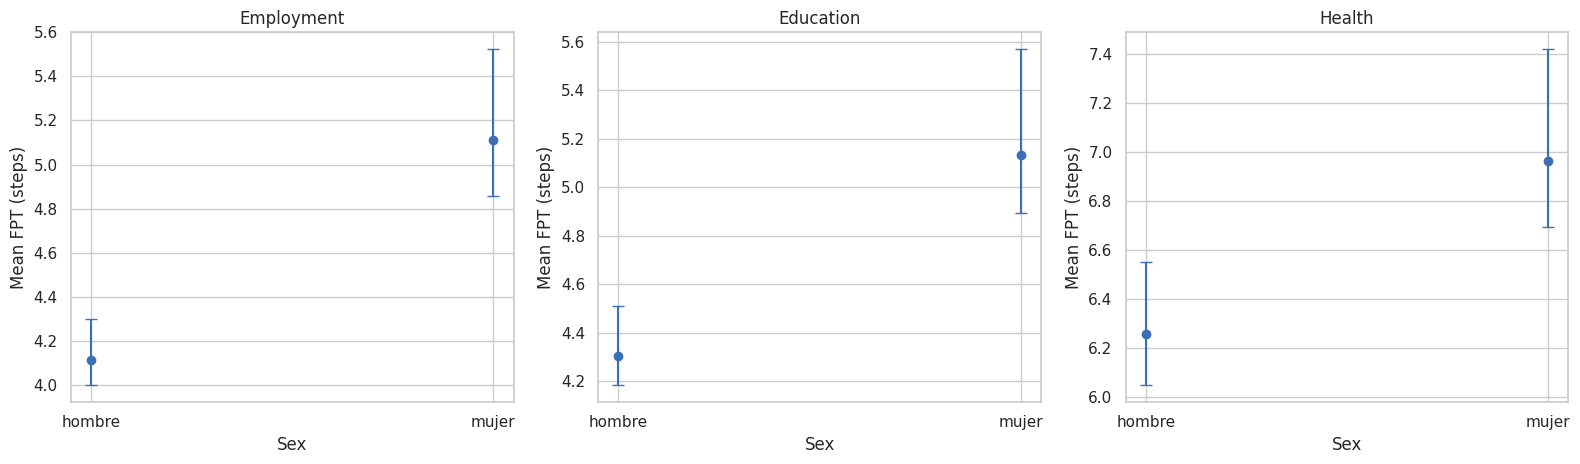

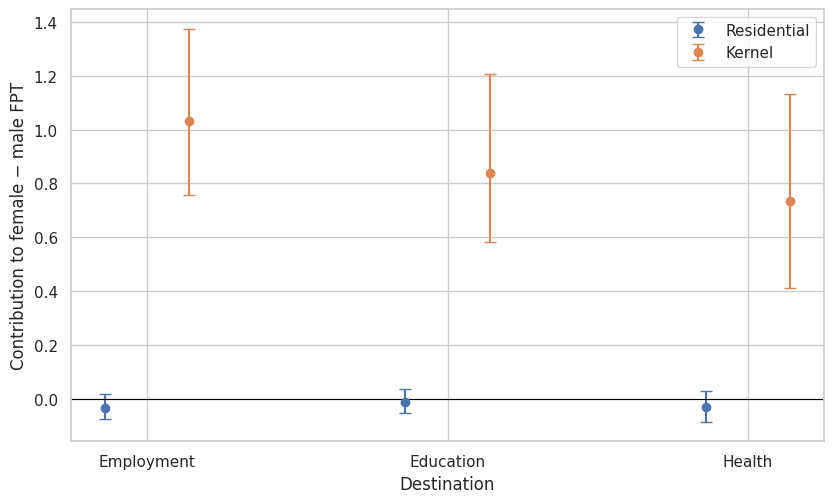

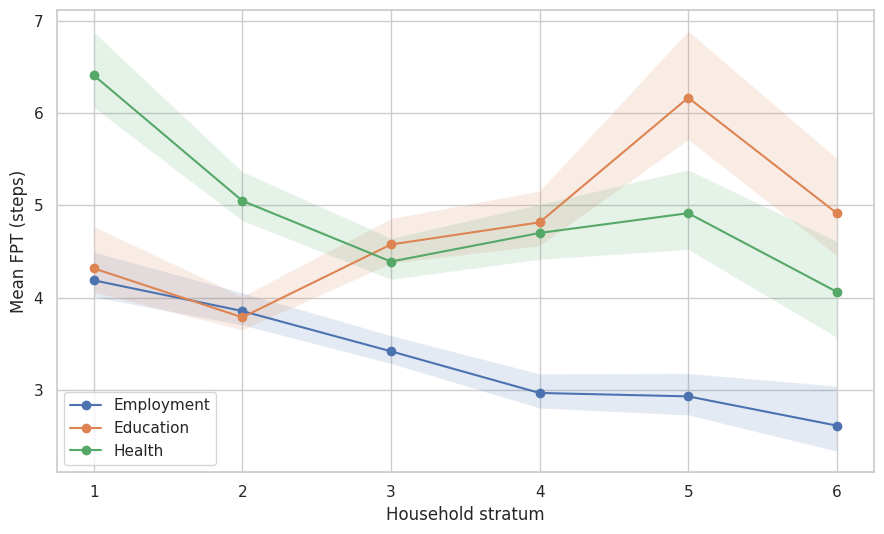

In [40]:
sex_observed = group_intervals[
    group_intervals["dimension"].eq("sex")
    & group_intervals["effect"].eq("group_observed")
].copy()
sex_observed["level"] = pd.Categorical(
    sex_observed["level"], categories=["hombre", "mujer"], ordered=True
)
sex_observed = sex_observed.sort_values(["purpose_group", "level"])

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, purpose in zip(axes, PURPOSES):
    subset = sex_observed[sex_observed["purpose_group"].eq(purpose)]
    x = np.arange(len(subset))
    y = subset["point_estimate"].to_numpy(dtype=float)
    lower = y - subset["ci_lower"].to_numpy(dtype=float)
    upper = subset["ci_upper"].to_numpy(dtype=float) - y
    axis.errorbar(x, y, yerr=[lower, upper], fmt="o", capsize=4, color="#3B6FB6")
    axis.set_xticks(x)
    axis.set_xticklabels(subset["level"])
    axis.set(title=purpose.title(), xlabel="Sex", ylabel="Mean FPT (steps)")
fig.tight_layout()
fig.savefig(OUT / "figure_final_sex_fpt.png", dpi=240, bbox_inches="tight")
plt.show()

decomp = sex_intervals[sex_intervals["effect"].isin(
    ["residential_contribution", "kernel_contribution"]
)].copy()
fig, axis = plt.subplots(figsize=(8.5, 5.2))
for offset, effect in enumerate(["residential_contribution", "kernel_contribution"]):
    subset = decomp[decomp["effect"].eq(effect)].set_index("purpose_group").reindex(PURPOSES)
    x = np.arange(len(PURPOSES)) + (offset - 0.5) * 0.28
    y = subset["point_estimate"].to_numpy(dtype=float)
    lower = y - subset["ci_lower"].to_numpy(dtype=float)
    upper = subset["ci_upper"].to_numpy(dtype=float) - y
    axis.errorbar(
        x, y, yerr=[lower, upper], fmt="o", capsize=4,
        label=effect.replace("_contribution", "").title(),
    )
axis.axhline(0, color="black", linewidth=0.8)
axis.set_xticks(np.arange(len(PURPOSES)))
axis.set_xticklabels([p.title() for p in PURPOSES])
axis.set(xlabel="Destination", ylabel="Contribution to female − male FPT")
axis.legend()
fig.tight_layout()
fig.savefig(OUT / "figure_final_sex_decomposition.png", dpi=240, bbox_inches="tight")
plt.show()

stratum_observed = group_intervals[
    group_intervals["dimension"].eq("stratum")
    & group_intervals["effect"].eq("group_observed")
].copy()
stratum_observed["level_numeric"] = pd.to_numeric(stratum_observed["level"])
fig, axis = plt.subplots(figsize=(9, 5.5))
for purpose in PURPOSES:
    subset = stratum_observed[
        stratum_observed["purpose_group"].eq(purpose)
    ].sort_values("level_numeric")
    axis.plot(subset["level_numeric"], subset["point_estimate"], marker="o", label=purpose.title())
    axis.fill_between(
        subset["level_numeric"].to_numpy(dtype=float),
        subset["ci_lower"].to_numpy(dtype=float),
        subset["ci_upper"].to_numpy(dtype=float), alpha=0.15,
    )
axis.set_xticks(range(1, 7))
axis.set(xlabel="Household stratum", ylabel="Mean FPT (steps)")
axis.legend()
fig.tight_layout()
fig.savefig(OUT / "figure_final_stratum_fpt.png", dpi=240, bbox_inches="tight")
plt.show()


## 7. Localización espacial de las contribuciones

Los colores divergentes distinguen UTAM que aumentan o reducen cada componente de la
brecha. Los rankings se basan en contribución absoluta para no ocultar compensaciones.


Capa UTAM: /content/colombia-stochastic-access/data/interim/bogota_em2023_gate11/zoning_edoh/03_Zonificacion EODH/a. Shapefile UTAM/UTAM2023/UTAM2023.shp
Cobertura espacial del kernel: 99.3%


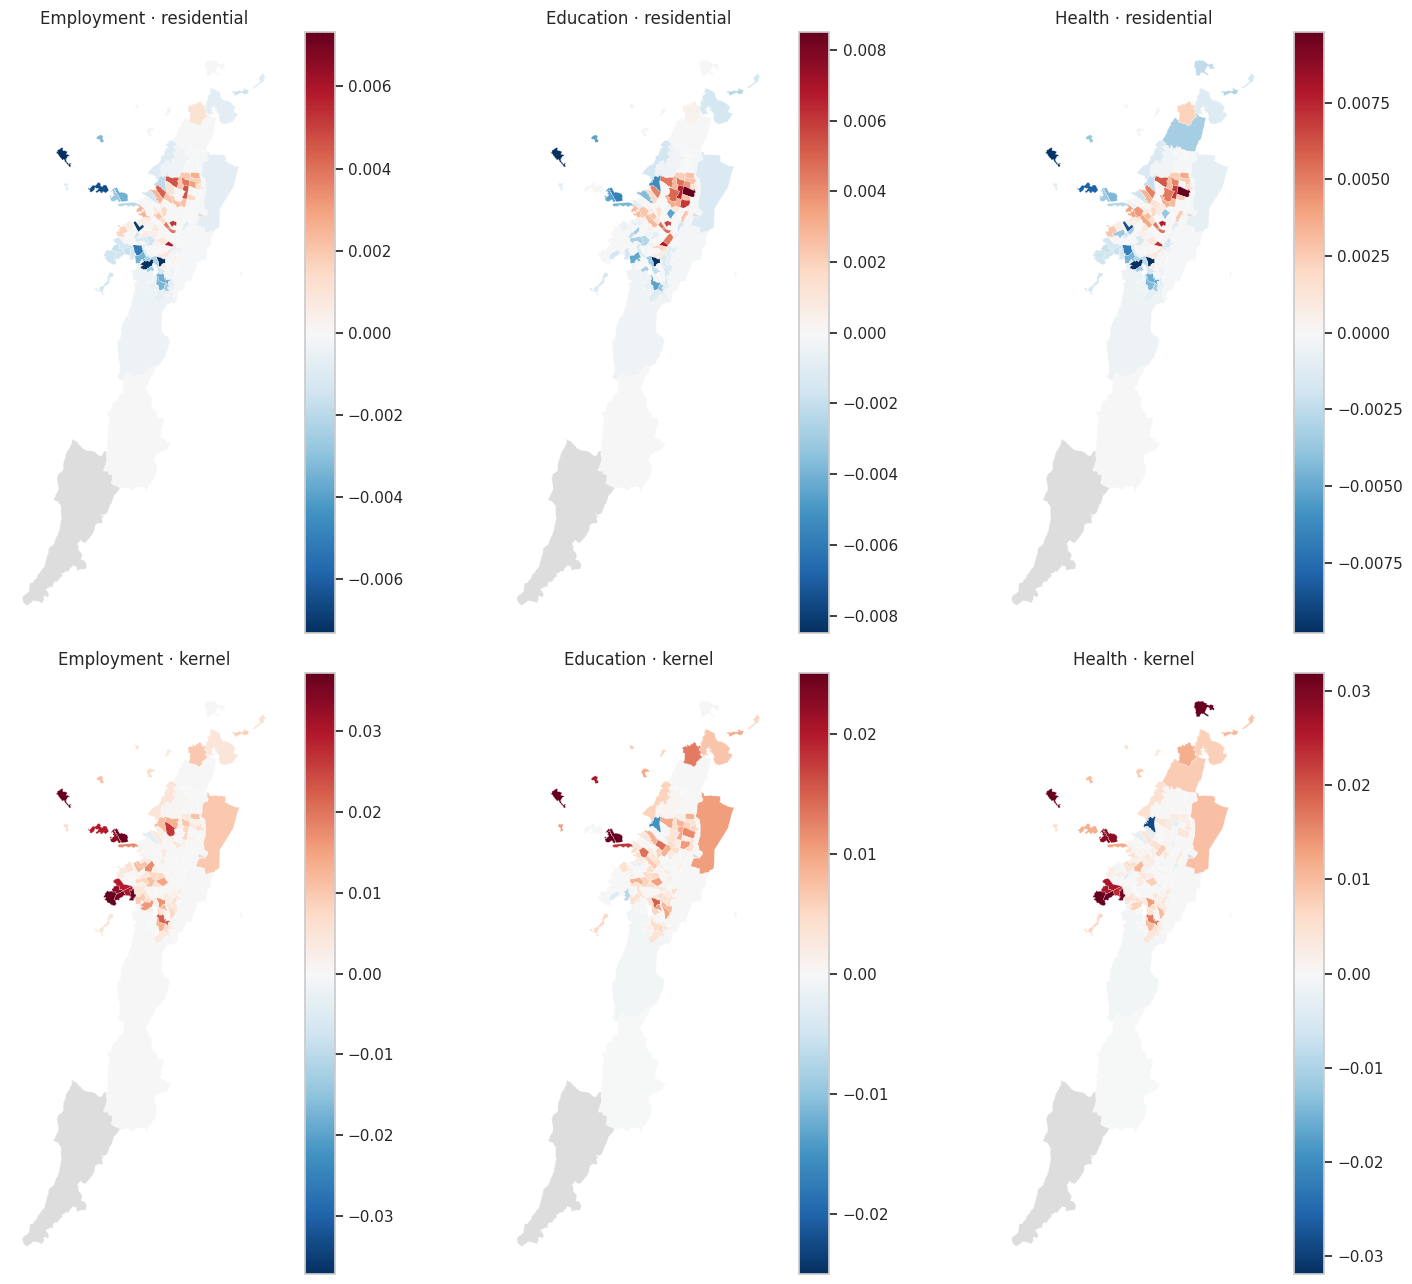

,purpose_group,component,rank_absolute,utam,contribution,absolute_share
0,employment,residential_contribution,1,UTAM054,-0.012708,0.065866
1,employment,residential_contribution,2,UTAM563,-0.008663,0.044901
2,employment,residential_contribution,3,UTAM067,-0.008454,0.043815
3,employment,residential_contribution,4,UTAM082,-0.006999,0.036275
4,employment,residential_contribution,5,UTAM540,-0.006541,0.033903
...,...,...,...,...,...,...
85,health,kernel_contribution,11,UTAM571,0.024116,0.028615
86,health,kernel_contribution,12,UTAM057,0.016535,0.019620
87,health,kernel_contribution,13,UTAM054,0.013690,0.016244
88,health,kernel_contribution,14,UTAM501,0.012322,0.014620


In [41]:
spatial_paths = sorted(
    list((INTERIM / "zoning_edoh").rglob("*.shp"))
    + list((INTERIM / "zoning_edoh").rglob("*.geojson"))
    + list((INTERIM / "zoning_edoh").rglob("*.gpkg"))
)
utam_candidates = []
for path in spatial_paths:
    try:
        preview = gpd.read_file(path, rows=5)
        normalized_columns = {normalize(column): column for column in preview.columns}
        if "utam" in normalized_columns:
            utam_candidates.append((path, normalized_columns["utam"]))
    except Exception:
        continue
if not utam_candidates:
    raise FileNotFoundError("No se encontró una capa espacial con identificador UTAM.")
utam_path, utam_column = sorted(
    utam_candidates, key=lambda item: ("utam2023" not in normalize(item[0].stem), len(item[0].parts))
)[0]
utam_map = gpd.read_file(utam_path)
utam_map["utam"] = canonical_utam(utam_map[utam_column])
utam_map = utam_map.dropna(subset=["utam"]).dissolve(by="utam", as_index=False)

mapped_nodes = set(utam_map["utam"]) & set(nodes)
spatial_coverage = float(len(mapped_nodes) / len(nodes))
print("Capa UTAM:", utam_path)
print("Cobertura espacial del kernel:", f"{spatial_coverage:.1%}")

components = ("residential_contribution", "kernel_contribution")
fig, axes = plt.subplots(2, 3, figsize=(16, 13))
for row_index, component in enumerate(components):
    for column_index, purpose in enumerate(PURPOSES):
        axis = axes[row_index, column_index]
        values = origin_contributions[
            origin_contributions["purpose_group"].eq(purpose)
        ][["utam", component]]
        layer = utam_map.merge(values, on="utam", how="left")
        limit = float(layer[component].abs().quantile(0.98))
        if not np.isfinite(limit) or limit == 0:
            limit = float(layer[component].abs().max()) or 1.0
        layer.plot(
            column=component, cmap="RdBu_r", vmin=-limit, vmax=limit,
            linewidth=0.15, edgecolor="white", legend=True, ax=axis,
            missing_kwds={"color": "#dddddd"},
        )
        axis.set_title(f"{purpose.title()} · {component.replace('_contribution', '')}")
        axis.set_axis_off()
fig.tight_layout()
fig.savefig(OUT / "figure_final_origin_contributions_map.png", dpi=240, bbox_inches="tight")
plt.show()

ranking_rows = []
for purpose in PURPOSES:
    frame = origin_contributions[origin_contributions["purpose_group"].eq(purpose)]
    for component in components:
        ordered = frame.assign(abs_value=frame[component].abs()).sort_values("abs_value", ascending=False)
        denominator = float(ordered["abs_value"].sum())
        for rank, row in enumerate(ordered.head(15).itertuples(index=False), start=1):
            ranking_rows.append({
                "purpose_group": purpose, "component": component,
                "rank_absolute": int(rank), "utam": row.utam,
                "contribution": float(getattr(row, component)),
                "absolute_share": float(abs(getattr(row, component)) / denominator),
            })
top_contributors = pd.DataFrame(ranking_rows)
top_contributors.to_csv(OUT / "top_origin_contributors.csv", index=False)
display(top_contributors)


## 8. Compuerta 11

La compuerta valida la inferencia computacional final y la trazabilidad espacial. No exige
que los intervalos excluyan cero ni que los gradientes tengan una dirección determinada.


In [42]:
gate9_sex = pd.read_csv(GATE9_SEX_PATH)
sex_replication = sex_point.merge(gate9_sex, on="purpose_group", suffixes=("_gate11", "_gate9"))
replication_columns = [
    "female_minus_male_total", "residential_contribution", "kernel_contribution"
]
replication_error = max(
    float((sex_replication[f"{column}_gate11"] - sex_replication[f"{column}_gate9"]).abs().max())
    for column in replication_columns
)
thresholds = {
    "maximum_gate9_replication_error": 1e-9,
    "maximum_decomposition_closure_error": 1e-10,
    "minimum_spatial_node_coverage": 0.95,
}
checks = {
    "gate10_dependency_valid": bool(gate10_status.get("gate_10_passed", False)),
    "primary_point_estimates_reproduced": bool(
        replication_error <= thresholds["maximum_gate9_replication_error"]
    ),
    "bootstrap_500_complete": bool(
        sex_boot["replicate"].nunique() == BOOTSTRAP_REPLICATES
        and len(sex_boot) == BOOTSTRAP_REPLICATES * len(PURPOSES)
        and len(group_boot) == BOOTSTRAP_REPLICATES * len(PURPOSES) * len(expected_groups)
    ),
    "bootstrap_intervals_finite": bool(
        np.isfinite(group_intervals[["ci_lower", "ci_upper"]].to_numpy()).all()
        and np.isfinite(sex_intervals[
            ["ci_lower", "ci_upper", "simultaneous_ci_lower", "simultaneous_ci_upper"]
        ].to_numpy()).all()
    ),
    "decomposition_identity_valid": bool(
        point["closure_error"].abs().max()
        <= thresholds["maximum_decomposition_closure_error"]
        and sex_point["closure_error"].abs().max()
        <= thresholds["maximum_decomposition_closure_error"]
    ),
    "origin_contribution_identity_valid": bool(
        origin_closure["closure_error"].abs().max()
        <= thresholds["maximum_decomposition_closure_error"]
    ),
    "spatial_coverage_valid": bool(
        spatial_coverage >= thresholds["minimum_spatial_node_coverage"]
    ),
    "stratum_intervals_finite": bool(
        np.isfinite(rho_intervals[["ci_lower", "ci_upper"]].to_numpy()).all()
    ),
}
checks["gate_11_passed"] = bool(all(checks.values()))

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "source_sha256": str(source_manifest.loc[0, "sha256"]),
    "estimand": "final household-bootstrap inference for primary FPT decomposition",
    "primary_specification": {
        "reference": "full_population", "target_definition": TARGET_DEFINITION,
        "conditioning": CONDITIONING, "regularization_tau": float(PRIMARY_TAU),
    },
    "bootstrap": {
        "method": "joint Poisson(1) household cluster bootstrap",
        "replicates": int(BOOTSTRAP_REPLICATES), "random_seed": int(RANDOM_SEED),
        "simultaneous_intervals": "bootstrap max-t within three-purpose families",
    },
    "spatial": {
        "zoning_source": ZONING_URL, "layer": str(utam_path),
        "kernel_node_coverage": float(spatial_coverage),
    },
    "thresholds": {key: float(value) for key, value in thresholds.items()},
    "sex_point_estimates": json.loads(sex_point.to_json(orient="records")),
    "stratum_spearman": json.loads(rho_intervals.to_json(orient="records")),
    "gate": checks,
}
(OUT / "gate_11.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8"
)
pd.Series(checks, name="result").to_csv(OUT / "gate_11_checks.csv")
display(pd.Series(checks, name="result"))

persistent_out = DRIVE_BASE / "results/gate11"
persistent_out.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent_out / artifact.name)

print("Compuerta 11:", "APROBADA" if checks["gate_11_passed"] else "NO APROBADA")
print("Copia persistente:", persistent_out)


,result
gate10_dependency_valid,True
primary_point_estimates_reproduced,True
bootstrap_500_complete,True
bootstrap_intervals_finite,True
decomposition_identity_valid,True
origin_contribution_identity_valid,True
spatial_coverage_valid,True
stratum_intervals_finite,True
gate_11_passed,True


Compuerta 11: APROBADA
Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate11


## Lectura posterior

- Los intervalos percentiles describen cada estimando; los simultáneos controlan la
  familia de empleo, educación y salud para cada componente.
- Los mapas identifican dónde se acumula la diferencia, no dónde una intervención tendría
  necesariamente un efecto causal.
- Los resultados por estrato siguen siendo descriptivos por la ausencia de estrato en una
  fracción importante de la muestra y por la mayor contracción de los estratos altos.
- Tras aprobar Gate 11, el siguiente producto será el paquete de resultados del manuscrito:
  narrativa, tablas finales, figuras y esquema de métodos.
